<a href="https://colab.research.google.com/github/maikalotsch/Maika-Lotsch_Chronic_Disease_DSRP_Project/blob/main/text.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
url = 'https://raw.githubusercontent.com/maikalotsch/Maika-Lotsch_Chronic_Disease_DSRP_Project/refs/heads/main/chronic_disease_data.csv'

df = pd.read_csv(url)

df.head(20)

,year,state_code,state_name,health_topic,indicator_metric,measurement_type,numeric_value,demographic_group
0,2019,AL,Alabama,Tobacco,Quit attempts in the past year among adult cur...,Crude Prevalence,NaN,"Hawaiian or Pacific Islander, non-Hispanic"
1,2019,CT,Connecticut,Cardiovascular Disease,High cholesterol among adults who have been sc...,Crude Prevalence,30.0,Hispanic
2,2019,DE,Delaware,Cardiovascular Disease,High blood pressure among adults,Crude Prevalence,38.8,"White, non-Hispanic"
3,2019,DE,Delaware,Cardiovascular Disease,Diseases of the heart mortality among all peop...,Number,2053.0,Overall
4,2019,DE,Delaware,Diabetes,Gestational diabetes among women with a recent...,Crude Prevalence,12.5,"White, non-Hispanic"
5,2019,GU,Guam,Cardiovascular Disease,High blood pressure among adults,Crude Prevalence,27.0,"Asian, non-Hispanic"
6,2019,HI,Hawaii,Diabetes,"Diabetes mortality among all people, underlyin...",Number,78.0,Hispanic
7,2019,IA,Iowa,Diabetes,Gestational diabetes among women with a recent...,Crude Prevalence,11.6,"Black, non-Hispanic"
8,2019,MD,Maryland,Diabetes,"Diabetes mortality among all people, underlyin...",Number,140.0,Hispanic
9,2019,MA,Massachusetts,Cardiovascular Disease,High blood pressure among adults,Age-adjusted Prevalence,42.8,Overall


In [ ]:
# detecting missing values in dataset (true = missing)
df.isnull().sum()

# drop missing data
df_clean = df.dropna(subset=['numeric_value'])

df_clean.head(20)

,year,state_code,state_name,health_topic,indicator_metric,measurement_type,numeric_value,demographic_group
1,2019,CT,Connecticut,Cardiovascular Disease,High cholesterol among adults who have been sc...,Crude Prevalence,30.0,Hispanic
2,2019,DE,Delaware,Cardiovascular Disease,High blood pressure among adults,Crude Prevalence,38.8,"White, non-Hispanic"
3,2019,DE,Delaware,Cardiovascular Disease,Diseases of the heart mortality among all peop...,Number,2053.0,Overall
4,2019,DE,Delaware,Diabetes,Gestational diabetes among women with a recent...,Crude Prevalence,12.5,"White, non-Hispanic"
5,2019,GU,Guam,Cardiovascular Disease,High blood pressure among adults,Crude Prevalence,27.0,"Asian, non-Hispanic"
6,2019,HI,Hawaii,Diabetes,"Diabetes mortality among all people, underlyin...",Number,78.0,Hispanic
7,2019,IA,Iowa,Diabetes,Gestational diabetes among women with a recent...,Crude Prevalence,11.6,"Black, non-Hispanic"
8,2019,MD,Maryland,Diabetes,"Diabetes mortality among all people, underlyin...",Number,140.0,Hispanic
9,2019,MA,Massachusetts,Cardiovascular Disease,High blood pressure among adults,Age-adjusted Prevalence,42.8,Overall
10,2019,MT,Montana,Cardiovascular Disease,High blood pressure among adults,Crude Prevalence,25.5,Hispanic


In [ ]:
# seperate numeric_value into own catigories
df_percentages = df_clean[df_clean['measurement_type'] == 'Crude Prevalence']
df_counts = df_clean[df_clean['measurement_type'] == 'Number']

print (df_percentages)
print(df_counts)

       year state_code   state_name            health_topic  \
1      2019         CT  Connecticut  Cardiovascular Disease   
2      2019         DE     Delaware  Cardiovascular Disease   
4      2019         DE     Delaware                Diabetes   
5      2019         GU         Guam  Cardiovascular Disease   
7      2019         IA         Iowa                Diabetes   
...     ...        ...          ...                     ...   
43970  2022         WY      Wyoming                 Tobacco   
43971  2022         WA   Washington                Diabetes   
43972  2022         WA   Washington                Diabetes   
43978  2022         UT         Utah                 Tobacco   
43981  2022         UT         Utah                 Tobacco   

                                        indicator_metric  measurement_type  \
1      High cholesterol among adults who have been sc...  Crude Prevalence   
2                       High blood pressure among adults  Crude Prevalence   
4      Ge

In [ ]:
# checking number of duplicates
duplicate_count = df.duplicated().sum()
df[df.duplicated()]

# no duplicates in this dataset

,year,state_code,state_name,health_topic,indicator_metric,measurement_type,numeric_value,demographic_group


In [ ]:
df["demographic_group"].unique()

array(['Hawaiian or Pacific Islander, non-Hispanic', 'Hispanic',
       'White, non-Hispanic', 'Overall', 'Asian, non-Hispanic',
       'Black, non-Hispanic', 'Multiracial, non-Hispanic',
       'American Indian or Alaska Native, non-Hispanic',
       'Asian or Pacific Islander, non-Hispanic'], dtype=object)

In [ ]:
df['indicator_metric'].unique()

array(['Quit attempts in the past year among adult current smokers',
       'High cholesterol among adults who have been screened',
       'High blood pressure among adults',
       'Diseases of the heart mortality among all people, underlying cause',
       'Gestational diabetes among women with a recent live birth',
       'Diabetes mortality among all people, underlying or contributing cause',
       'Taking medicine for high cholesterol among adults',
       'Cigarette smoking during pregnancy among women with a recent live birth',
       'Cerebrovascular disease (stroke) mortality among all people, underlying cause',
       'Coronary heart disease mortality among all people, underlying cause',
       'Diabetes among adults',
       'Diabetic ketoacidosis mortality among all people, underlying or contributing cause',
       'Current smokeless tobacco use among high school students',
       'Current cigarette smoking among adults',
       'Hospitalization for heart failure as princi

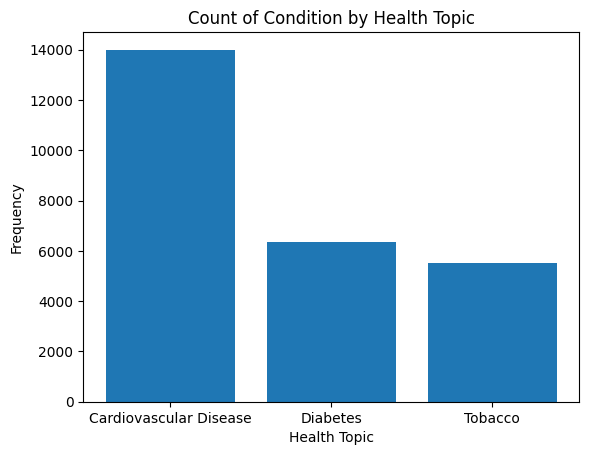

In [ ]:
# bar graph of count of condition by health topic
counts = df_clean["health_topic"].value_counts()
plt.bar (counts.index, counts.values)

plt.title("Count of Condition by Health Topic")
plt.xlabel("Health Topic")
plt.ylabel("Frequency")

plt.show()

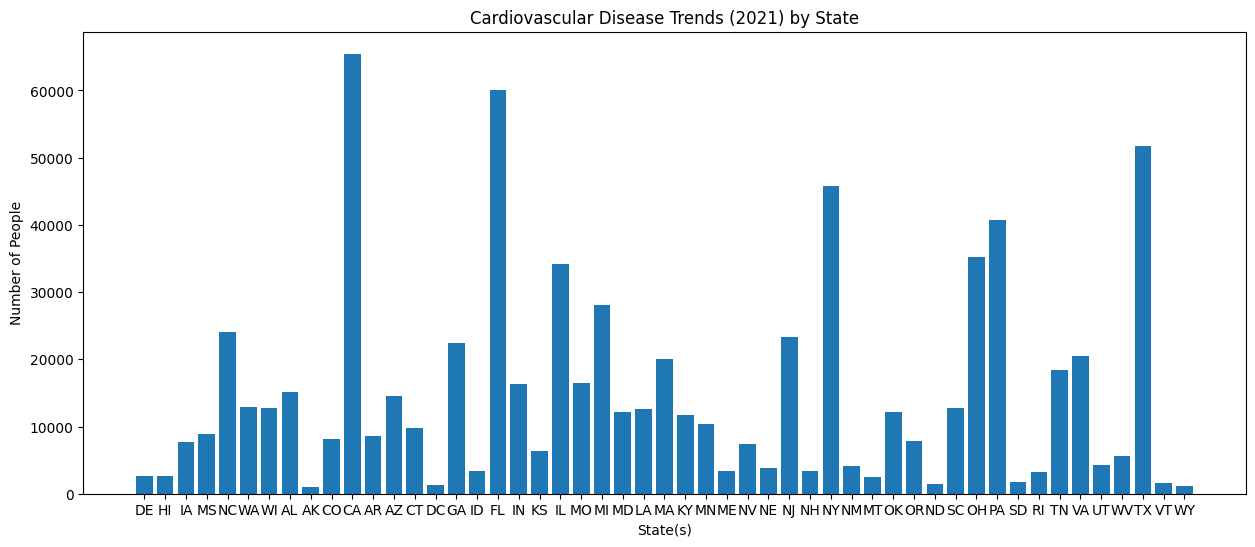

In [ ]:
# number of people with Cardiovascular Disease in each State 2021

!# Install and import matplotlib
!pip install matplotlib
import matplotlib.pyplot as plt

df = pd.read_csv(url)
df_clean = df.dropna(subset=['numeric_value'])


filtered_df = df_clean[
    (df_clean['health_topic'] == 'Cardiovascular Disease') &
    (df_clean['measurement_type'] == 'Number') &
    (df_clean['year']== 2021) &
    (df_clean['state_code'] != "US")]

x_categories = filtered_df['state_code']
y_heights = filtered_df['numeric_value']


plt.figure(figsize=(15, 6))
plt.bar(x_categories, y_heights)


plt.ylabel('Number of People')
plt.xlabel('State(s)')
plt.title('Cardiovascular Disease Trends (2021) by State')

plt.show()




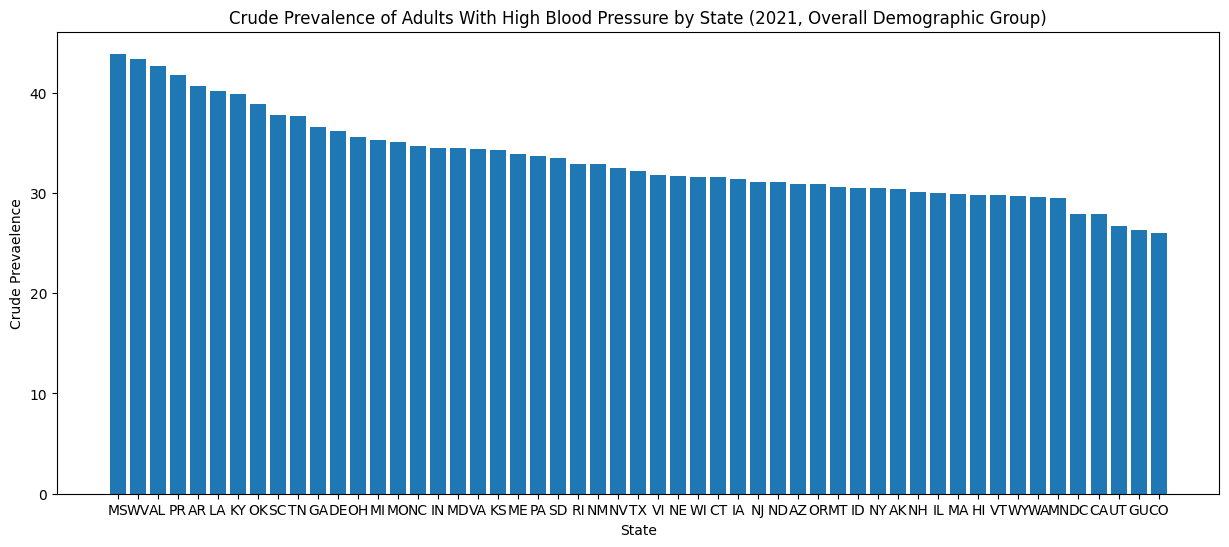

In [ ]:
filtered_df = df_clean[
    ((df_clean['health_topic'] == 'Cardiovascular Disease') &
    (df_clean['measurement_type'] == 'Crude Prevalence') &
    (df_clean['year']== 2021) &
    (df_clean['state_code'] != "US") &
    (df_clean['indicator_metric'] == "High blood pressure among adults") &
    (df_clean['demographic_group'] == 'Overall'))]

filtered_df = filtered_df.sort_values(by='numeric_value', ascending=False)

x_categories = filtered_df['state_code']
y_heights = filtered_df['numeric_value']

plt.figure(figsize=(15, 6))
plt.bar(x_categories, y_heights)

plt.ylabel('Crude Prevaelence')
plt.xlabel('State')
plt.title('Crude Prevalence of Adults With High Blood Pressure by State (2021, Overall Demographic Group)')

plt.show()



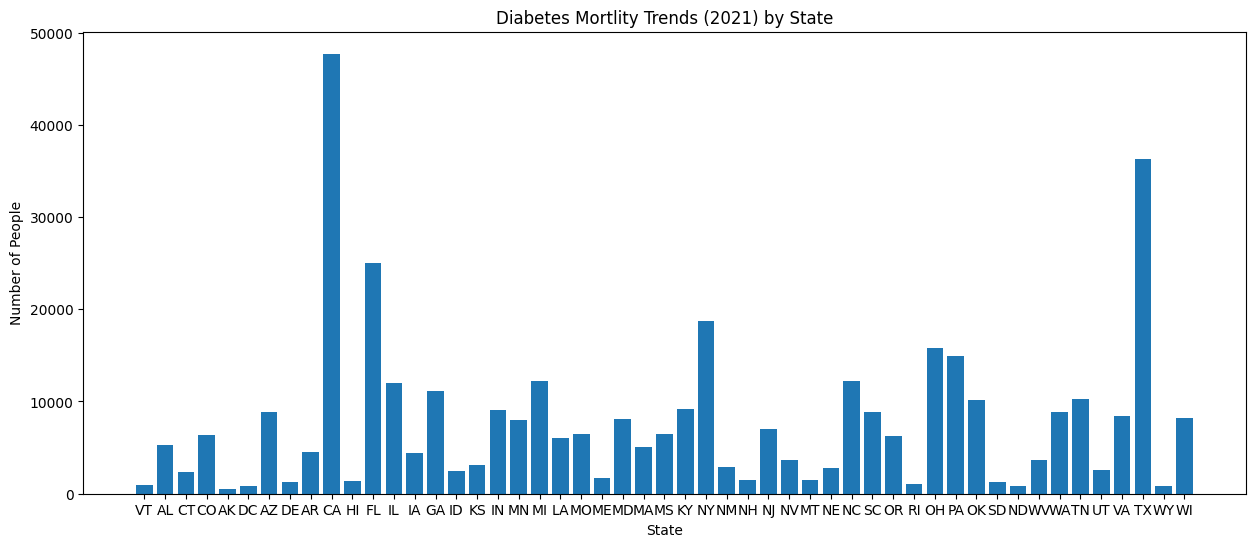

In [ ]:
# number of people with Diabetes in each State

!# Install and import matplotlib
!pip install matplotlib
import matplotlib.pyplot as plt

df = pd.read_csv(url)
df_clean = df.dropna(subset=['numeric_value'])


filtered_df = df_clean[
    (df_clean['health_topic'] == 'Diabetes') &
    (df_clean['measurement_type'] == 'Number') &
    (df_clean['demographic_group'] == 'Overall') &
    (df_clean['year']== 2021) &
    (df_clean['indicator_metric'] == 'Diabetes mortality among all people, underlying or contributing cause') &
    (df_clean['state_code'] != "US")]

x_categories = filtered_df['state_code']
y_heights = filtered_df['numeric_value']


plt.figure(figsize=(15, 6))
plt.bar(x_categories, y_heights)


plt.ylabel('Number of People')
plt.xlabel('State')
plt.title('Diabetes Mortlity Trends (2021) by State')

plt.show()

In [ ]:
df_clean.shape

(25875, 8)

In [ ]:
print('mean squared: ', mean_squared_error(y_test,pred))

print('r squared: ', r2_score(y_test, pred))

mean squared:  84.88799168896135
r squared:  0.08635804400232272


Plot saved successfully. r-value: 0.595, p-value: 3.355e-06


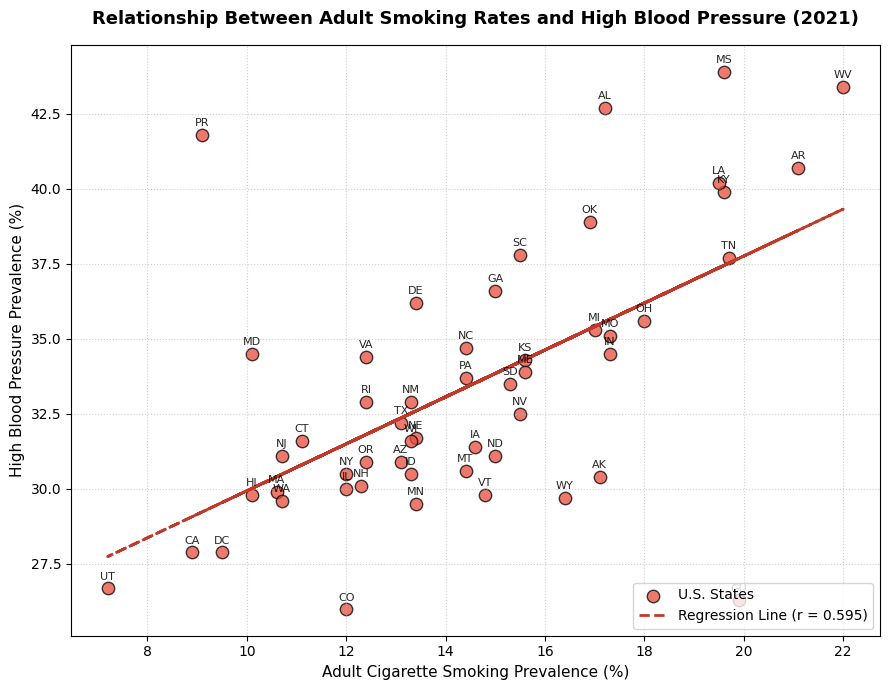

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress



# Filter for smoking
smoking = df_clean[
    (df_clean['indicator_metric'] == 'Current cigarette smoking among adults') &
    (df_clean['measurement_type'] == 'Crude Prevalence') &
    (df_clean['year'] == 2021) &
    (df_clean['state_code'] != 'US') &
    (df_clean['demographic_group'] == 'Overall')
][['state_code', 'numeric_value']].rename(columns={'numeric_value': 'smoking_rate'})

# Filter for high blood pressure
hbp = df_clean[
    (df_clean['indicator_metric'] == 'High blood pressure among adults') &
    (df_clean['measurement_type'] == 'Crude Prevalence') &
    (df_clean['year'] == 2021) &
    (df_clean['state_code'] != 'US') &
    (df_clean['demographic_group'] == 'Overall')
][['state_code', 'numeric_value']].rename(columns={'numeric_value': 'hypertension_rate'})

# Merge
merged_df = pd.merge(smoking, hbp, on='state_code').dropna()

# Linear regression
x = merged_df['smoking_rate']
y = merged_df['hypertension_rate']
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# Plotting using subplots (avoiding .figure() per guidelines)
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(x, y, color='#e74c3c', alpha=0.75, edgecolors='black', s=80, label='U.S. States')
ax.plot(x, slope*x + intercept, color='#c0392b', linewidth=2, linestyle='--',
        label=f'Regression Line (r = {r_value:.3f})')

# Annotate all state codes to provide complete information
for idx, row in merged_df.iterrows():
    ax.annotate(row['state_code'], (row['smoking_rate'], row['hypertension_rate']),
                 textcoords="offset points", xytext=(0,6), ha='center', fontsize=8, alpha=0.85)

# Styling
ax.set_title('Relationship Between Adult Smoking Rates and High Blood Pressure (2021)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Adult Cigarette Smoking Prevalence (%)', fontsize=11)
ax.set_ylabel('High Blood Pressure Prevalence (%)', fontsize=11)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='lower right', fontsize=10)

# Save figure without using show()
fig.tight_layout()
fig.savefig('smoking_vs_hypertension_scatter.png', dpi=300)
print(f"Plot saved successfully. r-value: {r_value:.3f}, p-value: {p_value:.3e}")

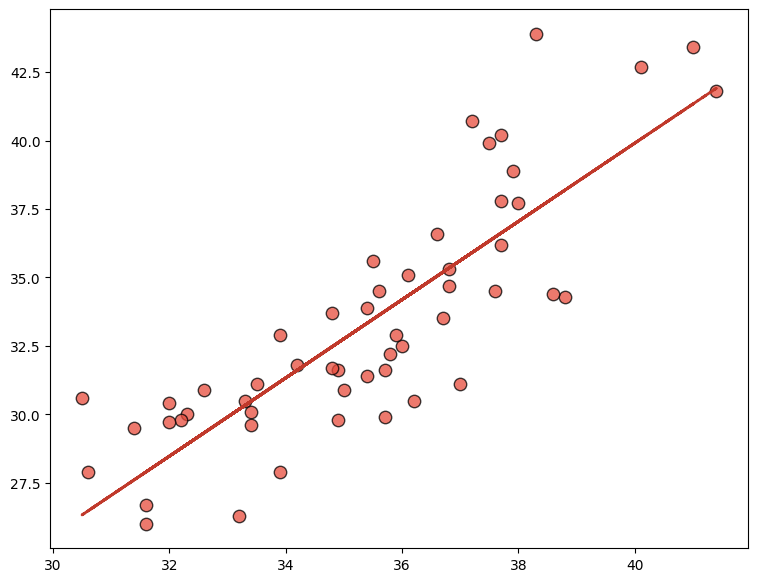

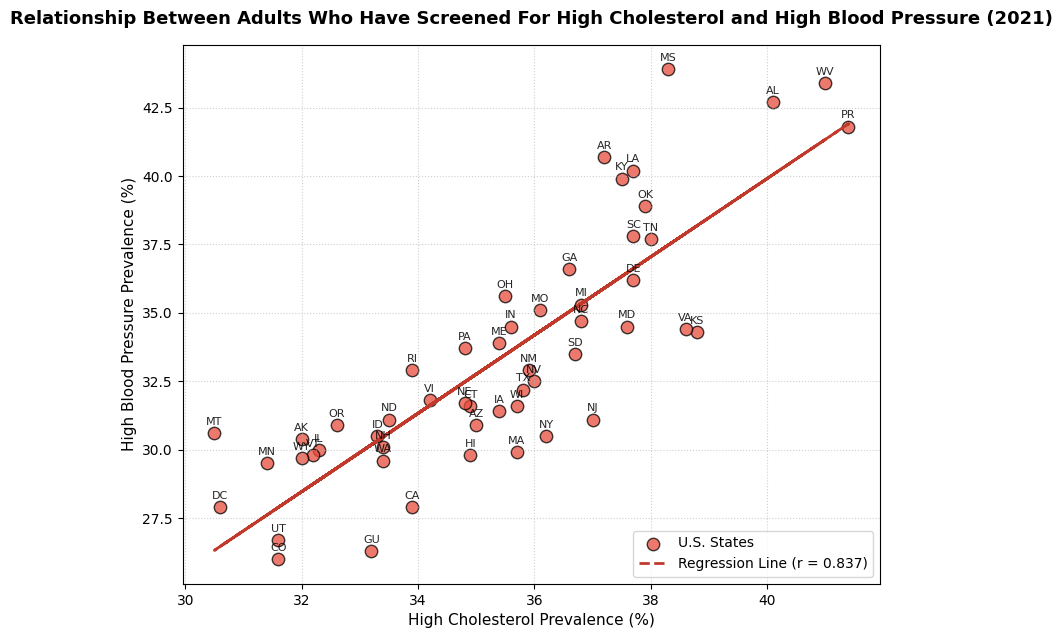

In [ ]:

# Filter for high cholestoral
high_cholesterol = df_clean[
    (df_clean['indicator_metric'] == 'High cholesterol among adults who have been screened') &
    (df_clean['measurement_type'] == 'Crude Prevalence') &
    (df_clean['year'] == 2021) &
    (df_clean['state_code'] != 'US') &
    (df_clean['demographic_group'] == 'Overall')
][['state_code', 'numeric_value']].rename(columns={'numeric_value': 'cholesterol_rate'})


high_blood_pressure = df_clean[
    (df_clean['indicator_metric'] == 'High blood pressure among adults') &
    (df_clean['measurement_type'] == 'Crude Prevalence') &
    (df_clean['year'] == 2021) &
    (df_clean['state_code'] != 'US') &
    (df_clean['demographic_group'] == 'Overall')
][['state_code', 'numeric_value']].rename(columns={'numeric_value': 'hypertension_rate'})

merged_df = pd.merge(high_cholesterol, high_blood_pressure, on='state_code').dropna()

x = merged_df['cholesterol_rate']
y = merged_df['hypertension_rate']
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# Plotting using subplots (avoiding .figure() per guidelines)
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(x, y, color='#e74c3c', alpha=0.75, edgecolors='black', s=80, label='U.S. States')
ax.plot(x, slope*x + intercept, color='#c0392b', linewidth=2, linestyle='--',
        label=f'Regression Line (r = {r_value:.3f})')


# Plotting using subplots (avoiding .figure() per guidelines)
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(x, y, color='#e74c3c', alpha=0.75, edgecolors='black', s=80, label='U.S. States')
ax.plot(x, slope*x + intercept, color='#c0392b', linewidth=2, linestyle='--',
        label=f'Regression Line (r = {r_value:.3f})')

# Annotate all state codes to provide complete information
for idx, row in merged_df.iterrows():
    ax.annotate(row['state_code'], (row['cholesterol_rate'], row['hypertension_rate']),
                 textcoords="offset points", xytext=(0,6), ha='center', fontsize=8, alpha=0.85)


# Styling
ax.set_title('Relationship Between Adults Who Have Screened For High Cholesterol and High Blood Pressure (2021)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('High Cholesterol Prevalence (%)', fontsize=11)
ax.set_ylabel('High Blood Pressure Prevalence (%)', fontsize=11)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='lower right', fontsize=10)


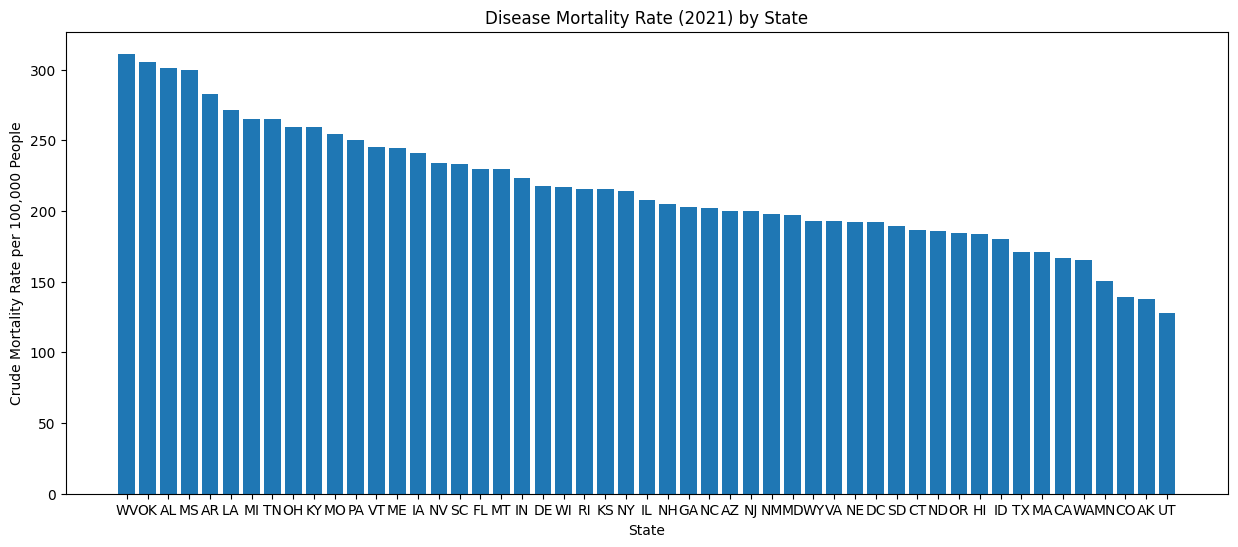

In [8]:
# graph showing the crude prevalence of cardiovascular disease by state


!# Install and import matplotlib
!pip install matplotlib
import matplotlib.pyplot as plt

df = pd.read_csv(url)
df_clean = df.dropna(subset=['numeric_value'])


filtered_df = df_clean[
    (df_clean['health_topic'] == 'Cardiovascular Disease') &
    (df_clean['measurement_type'] == 'Crude Rate') &
    (df_clean['year']== 2021) &
    (df_clean['indicator_metric'] == 'Diseases of the heart mortality among all people, underlying cause') &
    (df_clean['demographic_group'] == 'Overall') &
    (df_clean['state_code'] != "US")]

filtered_df = filtered_df.sort_values(by='numeric_value', ascending=False)

top5 = filtered_df.head(5)
bottom5 = filtered_df.tail(5)
top_bottom_df = pd.concat([top5, bottom5])

x_categories = filtered_df['state_code']
y_heights = filtered_df['numeric_value']




plt.figure(figsize=(15, 6))
plt.bar(x_categories, y_heights)


plt.ylabel('Crude Mortality Rate per 100,000 People')
plt.xlabel('State')
plt.title('Disease Mortality Rate (2021) by State')

plt.show()